## Computing PCA and AFD methods to analyze the dataset

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import scipy

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder




In [106]:
df = pd.read_csv("data/ObesityDataSet_raw_and_data_sinthetic.csv")
n, p =df.shape

In [107]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [108]:
df["IMC_index"] = df["Weight"]/(df["Height"]**2)

In [109]:
numerical_variables = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE", "IMC_index"]
categorical_variables = ["Gender", "family_history_with_overweight", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS", "NObeyesdad"]
labels = list(df["NObeyesdad"].unique())

In [110]:
def split_train_test(data : pd.DataFrame, test_ratio, y):
    shuffle = np.random.permutation(n)
    separator = int(test_ratio*n)
    tr_indices = shuffle[:separator]
    te_indices = shuffle[separator:]

    return data.iloc[tr_indices], data.iloc[te_indices], y[tr_indices], y[te_indices]
tr_data, te_data, y_tr, y_te = split_train_test(df, 0.8, df["NObeyesdad"])

In [111]:
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy='median')),
                        ("std_scaler", StandardScaler())])

full_pipeline = ColumnTransformer([("num", num_pipeline, numerical_variables),
                                   ("cat", OrdinalEncoder(), categorical_variables)])

tr_data = full_pipeline.fit_transform(tr_data)
te_data = full_pipeline.fit_transform(te_data)

In [112]:
import seaborn as sns

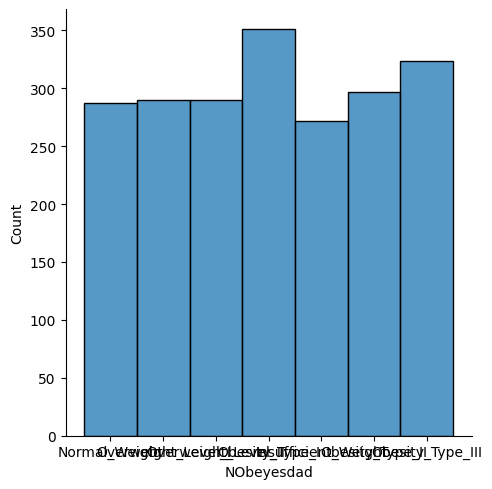

In [113]:
sns.displot(data=df, x = "NObeyesdad")

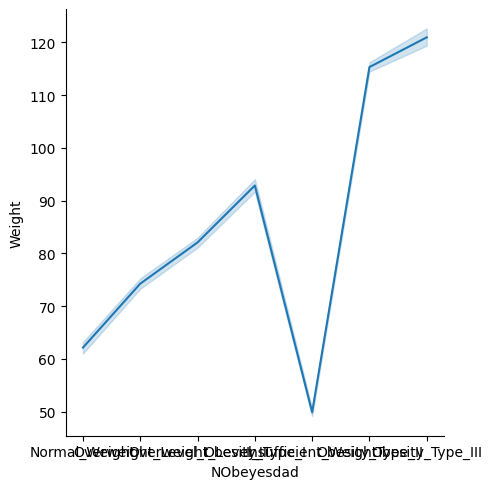

In [114]:
sns.relplot(data = df, x = "NObeyesdad", y = "Weight", kind = "line")

<Axes: xlabel='family_history_with_overweight', ylabel='IMC_index'>

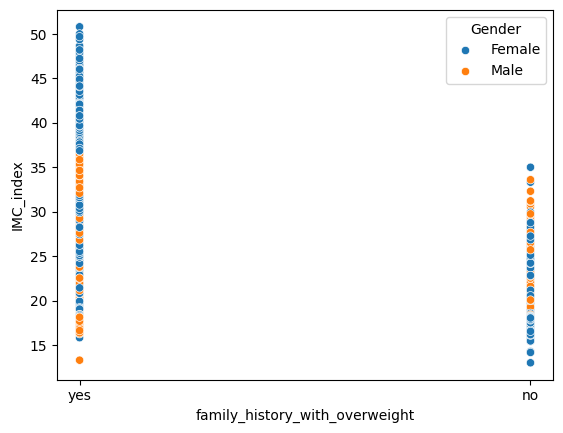

In [115]:
sns.scatterplot(data = df, x = "family_history_with_overweight", y = "IMC_index", hue = "Gender")

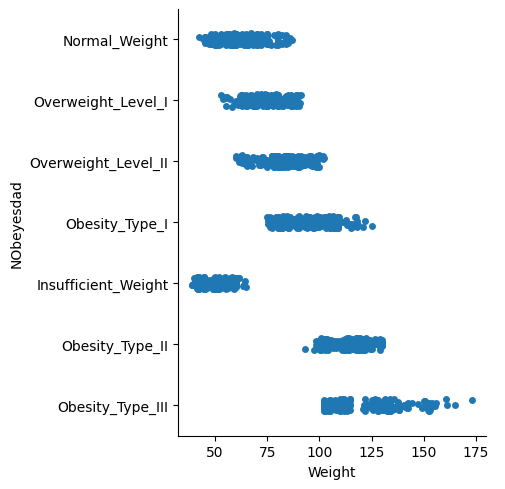

In [116]:
sns.catplot(data = df, x = "Weight", y = "NObeyesdad", kind = "strip")

In [117]:
tr_df = pd.DataFrame(tr_data, columns = full_pipeline.get_feature_names_out())

In [118]:
tr_df.corr()

,num__Age,num__Height,num__Weight,num__FCVC,num__NCP,num__CH2O,num__FAF,num__TUE,num__IMC_index,cat__Gender,cat__family_history_with_overweight,cat__FAVC,cat__CAEC,cat__SMOKE,cat__SCC,cat__CALC,cat__MTRANS,cat__NObeyesdad
num__Age,1.000000,-0.044782,0.192116,0.001194,-0.027217,-0.051595,-0.151929,-0.293639,0.240244,0.039514,0.214813,0.053753,0.082745,0.091702,-0.115629,-0.052980,-0.604786,0.224449
num__Height,-0.044782,1.000000,0.464337,-0.026981,0.261633,0.201537,0.290958,0.062200,0.131226,0.617797,0.243606,0.192029,0.051355,0.077259,-0.119226,-0.135994,-0.049837,0.030121
num__Weight,0.192116,0.464337,1.000000,0.221333,0.125042,0.194917,-0.044644,-0.076384,0.934124,0.172061,0.498754,0.261024,0.288467,0.049590,-0.182066,-0.215011,0.011432,0.378610
num__FCVC,0.001194,-0.026981,0.221333,1.000000,0.026769,0.086481,0.028095,-0.076099,0.263916,-0.263938,0.053860,-0.025771,-0.057776,0.011095,0.058888,-0.063368,0.081626,0.006193
num__NCP,-0.027217,0.261633,0.125042,0.026769,1.000000,0.060333,0.144171,0.033531,0.052725,0.081844,0.071655,0.005076,-0.087038,-0.012603,-0.011946,-0.082954,-0.074572,-0.068981
num__CH2O,-0.051595,0.201537,0.194917,0.086481,0.060333,1.000000,0.179664,-0.000463,0.142725,0.104937,0.144346,-0.000681,0.137183,-0.032536,0.022569,-0.076922,0.052321,0.109509
num__FAF,-0.151929,0.290958,-0.044644,0.028095,0.144171,0.179664,1.000000,0.058065,-0.168594,0.171728,-0.054342,-0.086902,-0.015059,0.011089,0.062999,0.091251,0.003955,-0.125124
num__TUE,-0.293639,0.062200,-0.076384,-0.076099,0.033531,-0.000463,0.058065,1.000000,-0.109433,0.019788,0.005329,0.067017,-0.047373,0.023003,-0.002467,0.052720,0.177464,-0.065833
num__IMC_index,0.240244,0.131226,0.934124,0.263916,0.052725,0.142725,-0.168594,-0.109433,1.000000,-0.042646,0.487195,0.227779,0.313406,0.016455,-0.166868,-0.177687,0.019876,0.423001
cat__Gender,0.039514,0.617797,0.172061,-0.263938,0.081844,0.104937,0.171728,0.019788,-0.042646,1.000000,0.112475,0.075716,0.105318,0.051992,-0.080966,-0.006653,-0.126986,0.032726


<Axes: >

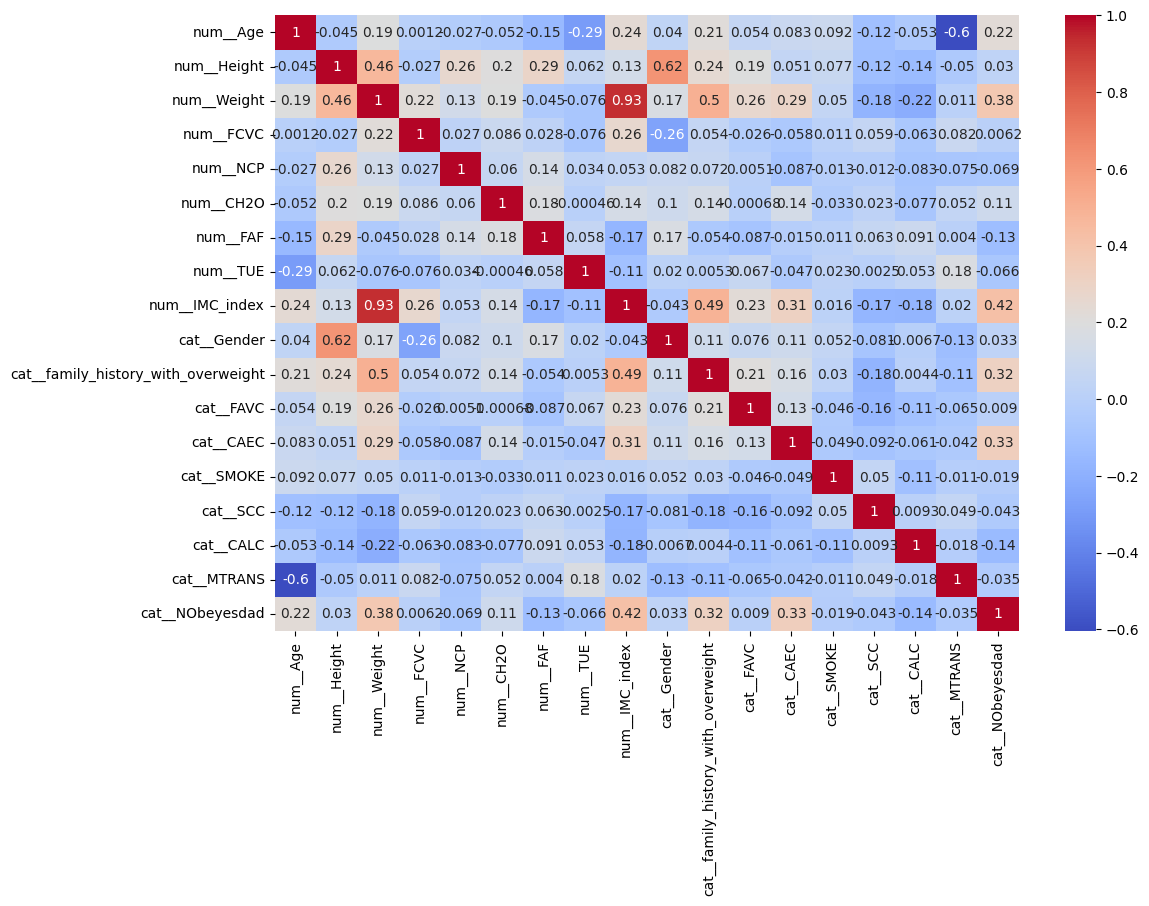

In [119]:
plt.figure(figsize=(12, 8))
sns.heatmap(tr_df.corr(), annot = True, cmap = "coolwarm")